In [16]:
#!python -m pip install --upgrade pip
#%pip install pandas matplotlib seaborn scikit-learn openpyxl tensorflow xgboost aif360
#%pip install "aif360[Reductions, inFairness]"

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint
from collections import Counter
from scipy.stats import chi2_contingency, fisher_exact

from fairlearn.metrics import MetricFrame
from fairlearn.metrics import demographic_parity_ratio, equalized_odds_ratio 
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference, selection_rate, false_positive_rate, false_negative_rate, count
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

import pickle

random_seed = 15

In [18]:
PATH = 'C:/Users/andre/Desktop/ProjectWork_AEQUITAS_AKKODIS/'

with open(PATH + 'data/predictions', 'rb') as f:
    data = pickle.load(f)

predictions = data['predictions']
references  = data['references']
sensitives  = data['sensitives']
sensitive_features = data['sensitive_name']

print(predictions)

{(1, 'Logistic Regression'): array([1, 1, 0, ..., 0, 1, 1]), (1, 'Linear Regression'): array([1, 1, 0, ..., 0, 0, 1]), (1, 'Decision Tree'): array([1, 1, 0, ..., 0, 1, 1]), (1, 'Naive Bayes'): array([1, 1, 0, ..., 0, 0, 1]), (1, 'XGBoost'): array([1, 1, 0, ..., 0, 1, 1]), (1, 'KNN'): array([0, 1, 1, ..., 0, 0, 0]), (1, 'Neural Network'): array([1, 1, 0, ..., 1, 1, 1]), (2, 'Logistic Regression'): array([0, 0, 0, ..., 1, 0, 0]), (2, 'Linear Regression'): array([0, 0, 0, ..., 0, 0, 0]), (2, 'Decision Tree'): array([0, 0, 0, ..., 1, 0, 0]), (2, 'Naive Bayes'): array([0, 0, 0, ..., 0, 0, 0]), (2, 'XGBoost'): array([0, 0, 0, ..., 1, 0, 0]), (2, 'KNN'): array([0, 0, 0, ..., 1, 0, 0]), (2, 'Neural Network'): array([0, 0, 0, ..., 1, 0, 0]), (3, 'Logistic Regression'): array([0, 1, 0, ..., 0, 0, 0]), (3, 'Linear Regression'): array([0, 1, 0, ..., 0, 0, 0]), (3, 'Decision Tree'): array([0, 1, 0, ..., 0, 0, 0]), (3, 'Naive Bayes'): array([0, 1, 0, ..., 0, 0, 0]), (3, 'XGBoost'): array([0, 1, 0, .

## Performance Metric

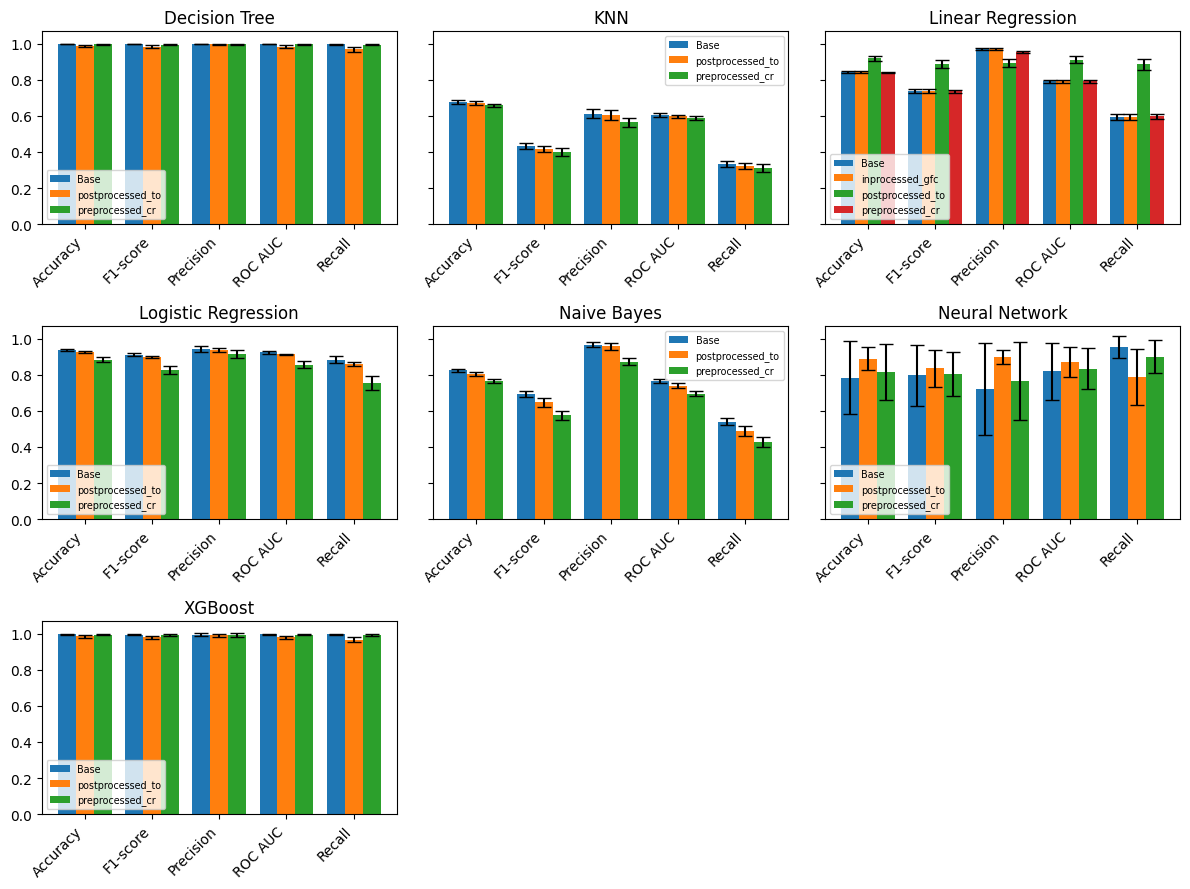

In [19]:
records = []
for (fold, name), y_pred in predictions.items():

    y_test = references[fold, name]
    y_sens = sensitives[fold, name]

    scores = {
        'Fold':       fold,
        'Model':      name,
        'Accuracy':   accuracy_score(y_test, y_pred),
        'Precision':  precision_score(y_test, y_pred),
        'Recall':     recall_score(y_test, y_pred),
        'F1-score':   f1_score(y_test, y_pred),
        'ROC AUC':    roc_auc_score(y_test, y_pred),
        'Group':      'Processed' if any(tag in name for tag in ['preprocessed','inprocessed','postprocessed'])
                    else 'Base'
    }
    records.append(scores)

df = pd.DataFrame(records).round(3)

df = df.melt(
                id_vars=['Fold','Model','Group'],
                value_vars=['Accuracy','Precision','Recall','F1-score','ROC AUC'],
                 var_name='Metric',
                value_name='Value'
                )

df = (
    df
    .groupby(['Model','Group','Metric'])['Value']
    .agg(['mean','std'])
    .reset_index()
)

base_models = df.loc[df.Group=='Base','Model'].unique()

ncols = 3
nrows = int(np.ceil(len(base_models)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3), sharey=True)
axes = axes.flatten()

pivot_mean = df.pivot(index='Metric', columns='Model', values='mean')
pivot_std  = df.pivot(index='Metric', columns='Model', values='std')

for ax, base in zip(axes, base_models):
    cols = [c for c in pivot_mean.columns if c.startswith(base)]
    x = np.arange(len(pivot_mean))
    width = 0.8 / len(cols)

    for i, var in enumerate(cols):
        label = var.replace(base + '_', '') if var != base else 'Base'
        ax.bar(
            x + (i - (len(cols)-1)/2)*width,
            pivot_mean[var],
            width,
            yerr=pivot_std[var],
            capsize=5,
            label=label
            )

    ax.set_xticks(x)
    ax.set_xticklabels(pivot_mean.index, rotation=45, ha='right')
    ax.set_title(base)
    ax.legend(fontsize='x-small')

for ax in axes[len(base_models):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Fairness Metrics

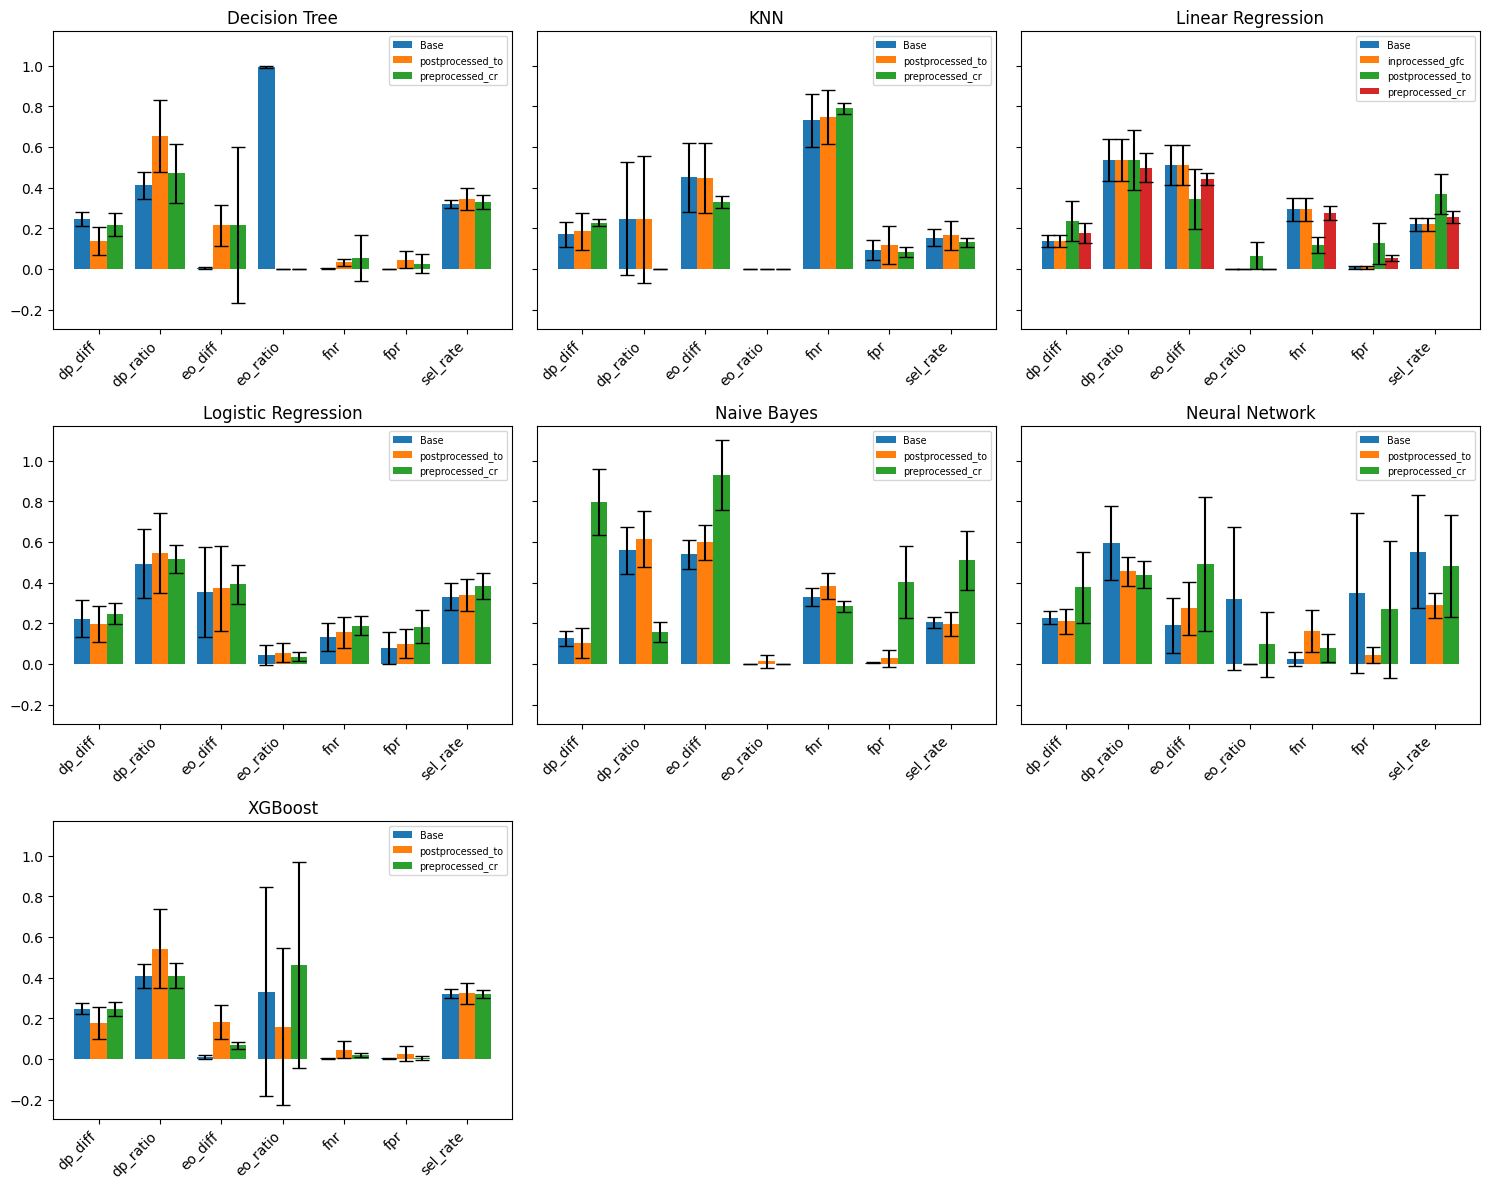

In [20]:
records = []
for (fold, name), y_pred in predictions.items():
    y_test = references[fold, name]
    s_test = sensitives[fold, name]
    sf_df = pd.DataFrame(s_test.tolist(), columns=sensitive_features)

    mf = MetricFrame(
        metrics={
            'sel_rate': selection_rate,
            'fpr': false_positive_rate,
            'fnr': false_negative_rate,
            'count': count
        },
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=sf_df
    )
    dp_diff   = demographic_parity_difference(y_test, y_pred, sensitive_features=sf_df)
    eo_diff   = equalized_odds_difference(y_test, y_pred, sensitive_features=sf_df)
    dp_ratio  = demographic_parity_ratio(y_test, y_pred, sensitive_features=sf_df)
    eo_ratio  = equalized_odds_ratio(y_test, y_pred, sensitive_features=sf_df)

    for group_val, metrics in mf.by_group.iterrows():
        for metric in ['sel_rate', 'fpr', 'fnr', 'count']:
            records.append({
                'Model':  name,
                'Group':  group_val,
                'Metric': metric,
                'Value':  metrics[metric]
            })

    records.append({'Model': name, 'Group': 'OverallDiff',  'Metric': 'dp_diff',   'Value': dp_diff})
    records.append({'Model': name, 'Group': 'OverallDiff',  'Metric': 'eo_diff',   'Value': eo_diff})
    records.append({'Model': name, 'Group': 'OverallRatio', 'Metric': 'dp_ratio',  'Value': dp_ratio})
    records.append({'Model': name, 'Group': 'OverallRatio', 'Metric': 'eo_ratio',  'Value': eo_ratio})

df = pd.DataFrame(records).round(3)

df = (
    df
    .groupby(['Model','Group','Metric'])['Value']
    .agg(['mean','std'])
    .reset_index()
)

base_models = [
    m for m in df['Model'].unique()
    if not any(tag in m for tag in ('preprocessed','inprocessed','postprocessed'))
]

ncols = 3
nrows = int(np.ceil(len(base_models) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4), sharey=True)
axes = axes.flatten()


global_diff = df[
    (df['Group'] == 'OverallDiff') &
    (df['Metric'].isin(['dp_diff','eo_diff']))
]

global_ratio = df[
    (df['Group'] == 'OverallRatio') &
    (df['Metric'].isin(['dp_ratio','eo_ratio']))
]

group_metrics = df[
    (df['Metric'].isin(['fnr','fpr','sel_rate'])) &
    (~df['Group'].isin(['OverallDiff','OverallRatio']))
]

group_agg = (
    group_metrics
    .groupby(['Model','Metric'])[['mean','std']]
    .mean()                 # media dei mean e media degli std
    .reset_index()
)

flat = pd.concat([global_diff, global_ratio, group_agg], ignore_index=True)

pivot_mean = flat.pivot(index='Metric', columns='Model', values='mean')
pivot_std  = flat.pivot(index='Metric', columns='Model', values='std')
    
for ax, base in zip(axes, base_models):
    cols = [c for c in pivot_mean.columns if c.startswith(base)]
    x = np.arange(len(pivot_mean))
    width = 0.8 / len(cols)

    for i, var in enumerate(cols):
        label = var.replace(base + '_', '') if var != base else 'Base'
        ax.bar(
            x + (i - (len(cols)-1)/2)*width,
            pivot_mean[var],
            width,
            yerr=pivot_std[var],
            capsize=5,
            label=label
        )

    ax.set_xticks(x)
    ax.set_xticklabels(pivot_mean.index, rotation=45, ha='right')
    ax.set_title(base)
    ax.legend(fontsize='x-small')

for ax in axes[len(base_models):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()